# Stage B - Fine-tuning ResNet-18 Classifier
Train an ImageNet-pretrained ResNet-18 expert on 100 classes with freeze/unfreeze scheduling.

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import yaml
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Ensure imports from project root work regardless of notebook working directory.
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset import get_dataloaders
from src.classifier import get_classifier
from src.train_classifier import train_classifier

In [2]:
config_path = project_root / 'configs' / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Resolve all important paths from the project root so notebook cwd does not matter.
data_root = (project_root / config['dataset']['root']).resolve()
models_dir = (project_root / 'models').resolve()
classifier_save_path = models_dir / 'resnet_classifier.pth'
classifier_ckpt_dir = models_dir / 'checkpoints' / 'classifier'

device = config['training']['device'] if torch.cuda.is_available() else 'cpu'
model = get_classifier(
    num_classes=config['dataset']['num_classes'],
    pretrained=config['classifier']['pretrained']
).to(device)
print(f'Using data root: {data_root}')
print(f'Checkpoint dir: {classifier_ckpt_dir}')
model

Using data root: C:\Users\Akash\Desktop\SelfHealingNN\data\raw
Checkpoint dir: C:\Users\Akash\Desktop\SelfHealingNN\models\checkpoints\classifier


SelfHealingClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

In [3]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,}')
print(f'Total params: {total:,}')

Trainable params: 11,227,812
Total params: 11,227,812


In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(
    root=str(data_root),
    image_size=config['dataset']['image_size'],
    batch_size=config['classifier']['batch_size'],
    train_split=config['dataset']['train_split'],
    num_workers=config['training']['num_workers'],
    noisy=False
)

# Single-call training with freeze->unfreeze schedule is safer for checkpoint resume.
history = train_classifier(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=config['classifier']['epochs'],
    learning_rate=config['classifier']['learning_rate'],
    freeze_backbone_epochs=int(config['classifier'].get('freeze_backbone_epochs', 5)),
    save_path=str(classifier_save_path),
    patience=config['training']['early_stopping_patience'],
    checkpoint_dir=str(classifier_ckpt_dir),
    checkpoint_interval=config['training']['checkpoint_interval'],
    auto_resume=config['training']['auto_resume'],
    use_amp=config['training']['amp'],
    grad_clip_norm=config['training']['grad_clip_norm'],
    early_stop_metric=str(config['training'].get('classifier_early_stop_metric', 'val_top1')),
    weight_decay=float(config['classifier'].get('weight_decay', 1e-4)),
    label_smoothing=float(config['classifier'].get('label_smoothing', 0.1)),
    mixup_alpha=float(config['classifier'].get('mixup_alpha', 0.2)),
)

print('Training call complete. If interrupted, rerun this cell to resume from latest checkpoint.')

C:\Users\Akash\Desktop\SelfHealingNN\src\train_classifier.py:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_checkpoint, map_location=devic

[Classifier] Resuming from epoch 12 (latest checkpoint).


Epoch 012 | loss=0.1615/0.1516 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.9640/0.9591 | lr=8.64e-05
Early stopping triggered at epoch 12.
Training call complete. If interrupted, rerun this cell to resume from latest checkpoint.


In [9]:
# Resume note: this notebook now uses a single training call in Cell 5.
# If you stop training manually, just rerun Cell 5 and it will auto-resume from
# models/checkpoints/classifier/latest.pt.
print('Resume workflow enabled: rerun Cell 5 to continue training from latest checkpoint.')

Resume workflow enabled: rerun Cell 5 to continue training from latest checkpoint.


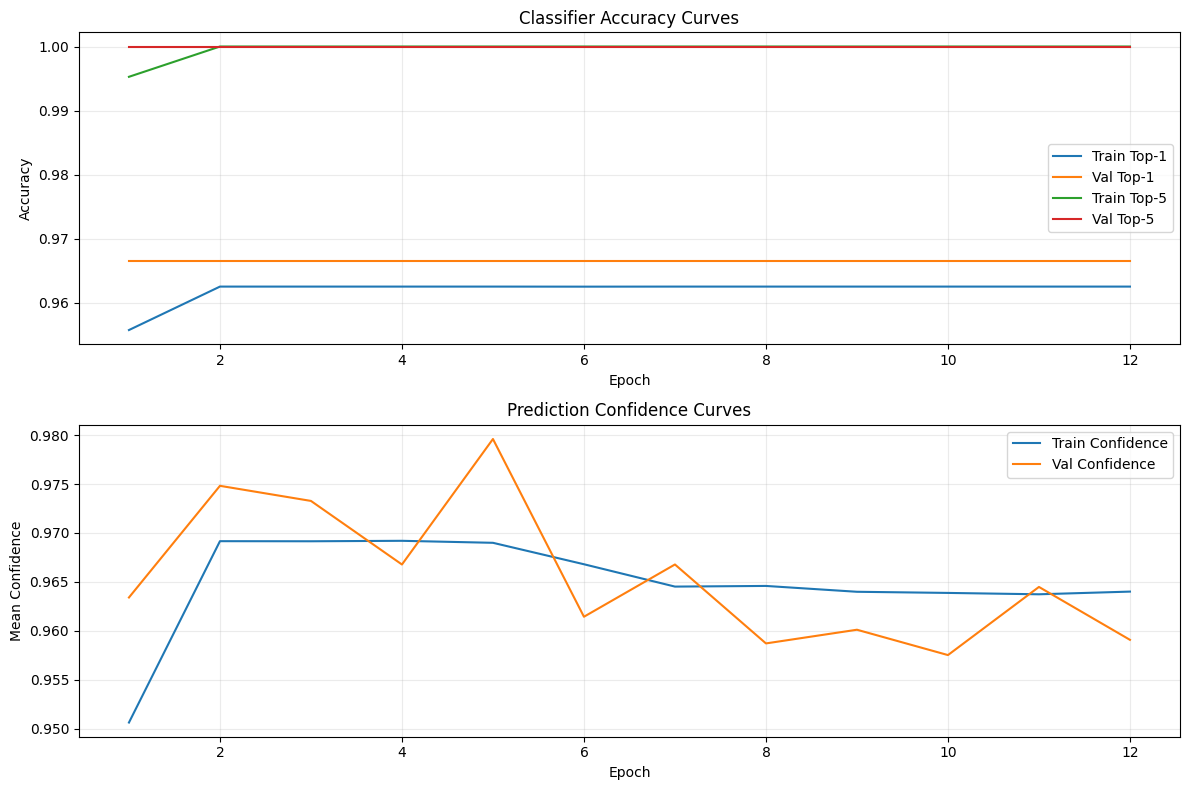

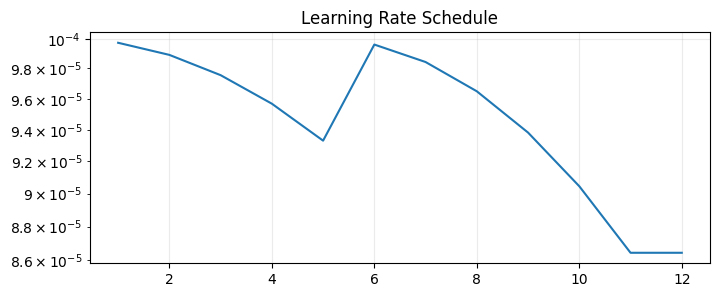

In [10]:
epochs = range(1, len(history['train_top1']) + 1)
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(epochs, history['train_top1'], label='Train Top-1')
plt.plot(epochs, history['val_top1'], label='Val Top-1')
plt.plot(epochs, history['train_top5'], label='Train Top-5')
plt.plot(epochs, history['val_top5'], label='Val Top-5')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracy Curves')
plt.legend()
plt.grid(alpha=0.25)

plt.subplot(2, 1, 2)
plt.plot(epochs, history.get('train_confidence', []), label='Train Confidence')
plt.plot(epochs, history.get('val_confidence', []), label='Val Confidence')
plt.xlabel('Epoch')
plt.ylabel('Mean Confidence')
plt.title('Prediction Confidence Curves')
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

if history.get('lr'):
    plt.figure(figsize=(8, 3))
    plt.plot(epochs, history['lr'])
    plt.title('Learning Rate Schedule')
    plt.yscale('log')
    plt.grid(alpha=0.25)
    plt.show()

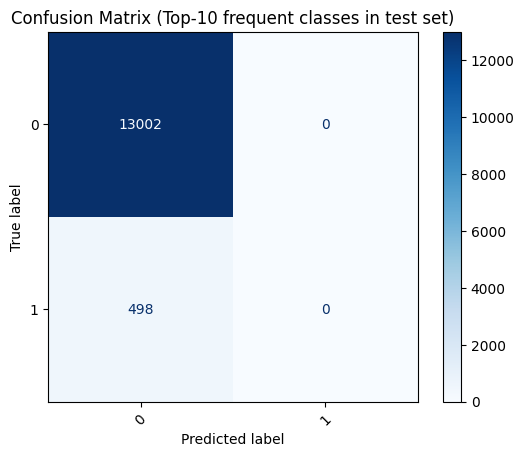

In [11]:
from collections import Counter

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

class_counts = Counter(all_targets.tolist())
sample_classes = [cls for cls, _ in class_counts.most_common(10)]
cm = confusion_matrix(all_targets, all_preds, labels=sample_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sample_classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix (Top-10 frequent classes in test set)')
plt.show()

In [12]:
top1_correct, top5_correct, total = 0, 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        top1 = logits.argmax(dim=1).cpu()
        top5 = logits.topk(5, dim=1).indices.cpu()
        top1_correct += top1.eq(labels).sum().item()
        matches = top5.eq(labels.view(-1, 1))
        top5_correct += matches.any(dim=1).sum().item()
        total += labels.size(0)

print(f"Top-1 Accuracy: {100.0 * top1_correct / max(total,1):.2f}%")
print(f"Top-5 Accuracy: {100.0 * top5_correct / max(total,1):.2f}%")

Top-1 Accuracy: 96.31%
Top-5 Accuracy: 100.00%


In [ ]:
from src.dataset import NoiseInjector
import pandas as pd

injector = NoiseInjector()
noise_levels = [0.1, 0.2, 0.3, 0.5, 0.7]
robust_rows = []

model.eval()
with torch.no_grad():
    for level in noise_levels:
        top1_sum, top5_sum, count = 0.0, 0.0, 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            noisy = torch.stack([injector.add_gaussian_noise(img, std=level) for img in images])
            logits = model(noisy)
            top1 = logits.argmax(dim=1).eq(labels).float().sum().item()
            top5 = logits.topk(5, dim=1).indices.eq(labels.view(-1, 1)).any(dim=1).float().sum().item()
            top1_sum += top1
            top5_sum += top5
            count += labels.size(0)

        robust_rows.append({
            'noise': float(level),
            'top1': 100.0 * top1_sum / max(count, 1),
            'top5': 100.0 * top5_sum / max(count, 1),
        })

robust_df = pd.DataFrame(robust_rows)
display(robust_df)

best_epoch = int(np.argmax(history['val_top1'])) + 1 if history.get('val_top1') else None
if best_epoch is not None:
    print(f'Best validation top-1 epoch: {best_epoch}')
    print(f"Best val top-1: {100.0 * history['val_top1'][best_epoch - 1]:.2f}%")
    print(f"Best val top-5: {100.0 * history['val_top5'][best_epoch - 1]:.2f}%")

report = {
    'best_epoch': best_epoch,
    'best_val_top1_percent': float(100.0 * history['val_top1'][best_epoch - 1]) if best_epoch is not None else None,
    'best_val_top5_percent': float(100.0 * history['val_top5'][best_epoch - 1]) if best_epoch is not None else None,
    'test_clean_top1_percent': float(100.0 * top1_correct / max(total, 1)),
    'test_clean_top5_percent': float(100.0 * top5_correct / max(total, 1)),
    'robustness_curve': robust_rows,
}

report_path = project_root / 'outputs' / 'results' / 'classifier_metrics.json'
report_path.parent.mkdir(parents=True, exist_ok=True)
import json
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2)

print(f'Saved classifier report to: {report_path.resolve()}')

## Summary
This notebook now reports both clean test accuracy and noise-robustness curves for the classifier-only stage.
It also exports a reproducible metrics file: `outputs/results/classifier_metrics.json`.